# Vision-Based Landslide Forecasting
## Phase 1: Pre-Event Forecasting Model (Baseline CNN & ResNet50)
This notebook trains an experimental forecasting model using strictly pre-event imagery (Jan-Oct 2025) and enforces strict geographic isolation.

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization, Input
)

print('Num GPUs Available: ', len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


## 1. Load Data and Verify Dates/Classes
Before training, we must strictly verify that the dataset contains only pre-event images and is balanced.

In [10]:
metadata_path = 'dataset_version_2/metadata.csv'
df = pd.read_csv(metadata_path)

# Verify no missing images
df = df[df['image_path'].apply(os.path.exists)]

print("--- Date Verification ---")
print(f"Earliest image: {df['acquisition_date'].min()}")
print(f"Latest image: {df['acquisition_date'].max()}")
print("\nAcquisition date distribution:")
print(df.groupby('label')['acquisition_date'].agg(['min', 'max']))

print("\n--- Class Verification (Overall) ---")
print(df['label'].value_counts())

--- Date Verification ---
Earliest image: 2026-01-01
Latest image: 2026-01-01

Acquisition date distribution:
              min         max
label                        
0      2026-01-01  2026-01-01
1      2026-01-01  2026-01-01

--- Class Verification (Overall) ---
label
1    5
0    5
Name: count, dtype: int64


## 2. Geographic Split (Train / Val / Test)
We use `GroupShuffleSplit` on `landslide_id` to strictly prevent spatial data leakage.

In [11]:
# 60% Train, 40% Temp
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.6, random_state=6)
train_idx, temp_idx = next(gss1.split(df, groups=df['landslide_id']))
df_train = df.iloc[train_idx].copy()
df_temp = df.iloc[temp_idx].copy()

# 20% Val, 20% Test (50% of the Temp 40%)
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=6)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['landslide_id']))
df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

print("--- Geographic Leakage Verification ---")
print("Train groups:", df_train['landslide_id'].nunique())
print("Val groups:", df_val['landslide_id'].nunique())
print("Test groups:", df_test['landslide_id'].nunique())

print("Train/Val overlap:", len(set(df_train['landslide_id']) & set(df_val['landslide_id'])))
print("Train/Test overlap:", len(set(df_train['landslide_id']) & set(df_test['landslide_id'])))
print("Val/Test overlap:", len(set(df_val['landslide_id']) & set(df_test['landslide_id'])))

print("\n--- Class Verification (Splits) ---")
print("TRAIN:\n", df_train['label'].value_counts())
print("VALIDATION:\n", df_val['label'].value_counts())
print("TEST:\n", df_test['label'].value_counts())

--- Geographic Leakage Verification ---
Train groups: 6
Val groups: 2
Test groups: 2
Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0

--- Class Verification (Splits) ---
TRAIN:
 label
1    3
0    3
Name: count, dtype: int64
VALIDATION:
 label
1    1
0    1
Name: count, dtype: int64
TEST:
 label
1    1
0    1
Name: count, dtype: int64


## 3. Data Generators and Augmentation
We set up two different data generators. The Baseline CNN uses standard 1/255 rescaling, but ResNet50 requires its own specific `preprocess_input` function.

In [12]:
# Generator for Baseline CNN (rescale 1/255) - heavy augmentation
cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
cnn_val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generator for ResNet50 (uses preprocess_input)
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
resnet_val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

df_train['label_str'] = df_train['label'].astype(str)
df_val['label_str']   = df_val['label'].astype(str)
df_test['label_str']  = df_test['label'].astype(str)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

def create_generators(train_gen, val_test_gen):
    train = train_gen.flow_from_dataframe(
        dataframe=df_train, x_col='image_path', y_col='label_str',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=['0', '1'], class_mode='binary', shuffle=True)
    val = val_test_gen.flow_from_dataframe(
        dataframe=df_val, x_col='image_path', y_col='label_str',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=['0', '1'], class_mode='binary', shuffle=False)
    test = val_test_gen.flow_from_dataframe(
        dataframe=df_test, x_col='image_path', y_col='label_str',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=['0', '1'], class_mode='binary', shuffle=False)
    return train, val, test

cnn_train_gen, cnn_val_gen, cnn_test_gen             = create_generators(cnn_train_datagen, cnn_val_test_datagen)
resnet_train_gen, resnet_val_gen, resnet_test_gen    = create_generators(resnet_train_datagen, resnet_val_test_datagen)
print('Generators ready.')

Found 6 validated image filenames belonging to 2 classes.
Found 2 validated image filenames belonging to 2 classes.
Found 2 validated image filenames belonging to 2 classes.
Found 6 validated image filenames belonging to 2 classes.
Found 2 validated image filenames belonging to 2 classes.
Found 2 validated image filenames belonging to 2 classes.
Generators ready.


## 4. Class Weights & Callbacks (Early Stopping)

In [13]:
neg, pos = np.bincount(df_train['label'])
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f'Class weights -> 0 (No Landslide): {weight_for_0:.3f} | 1 (Landslide): {weight_for_1:.3f}')

# Callbacks: EarlyStopping + ReduceLROnPlateau
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

Class weights -> 0 (No Landslide): 1.000 | 1 (Landslide): 1.000


## 5. Model 1: Baseline CNN

In [14]:
# Import layers needed for this cell
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization
)

# ============================================================
# MODEL 1: IMPROVED BASELINE CNN
# Changes from original:
#   1. Flatten() -> GlobalAveragePooling2D()  (less params, less overfitting)
#   2. BatchNormalization added per block     (stable, faster training)
#   3. Double Conv layers per block           (richer feature extraction)
#   4. 4th block with 256 filters             (deeper feature learning)
#   5. ReduceLROnPlateau callback             (auto LR tuning)
# ============================================================

baseline_model = Sequential([
    # Block 1: 32 filters
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2: 64 filters
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3: 128 filters
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4: 256 filters (new)
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classifier Head - GlobalAveragePooling instead of Flatten
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Improved_Baseline_CNN')

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

baseline_model.summary()

history_baseline = baseline_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Improved_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,321 (2.55 MB)

 Trainable params: 666,401 (2.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3333 - auc: 0.6667 - loss: 0.7069 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step - accuracy: 0.6667 - auc: 0.7778 - loss: 0.6837 - precision: 0.6667 - recall: 0.6667 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6927 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - accuracy: 0.6667 - auc: 0.6667 - loss: 1.0586 - precision: 1.0000 - recall: 0.3333 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6922 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step - accuracy: 0.8333 - auc: 1.0000 - loss: 0.3299 - precision: 0.7500 - recall: 1.0000 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6928 

In [15]:
import os
os.makedirs('saved_models', exist_ok=True)

# Modern format (.keras) - recommended
baseline_model.save('saved_models/baseline_cnn.keras')
print("Model saved -> saved_models/baseline_cnn.keras")


Model saved -> saved_models/baseline_cnn.keras


In [16]:
history_baseline = baseline_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

# ── Model Save ────────────────────────────────────────────────
import os
os.makedirs('saved_models', exist_ok=True)

# Modern format (.keras) - recommended
baseline_model.save('saved_models/baseline_cnn.keras')
print("Model saved -> saved_models/baseline_cnn.keras")


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.3962 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6923 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step - accuracy: 0.8333 - auc: 1.0000 - loss: 0.3904 - precision: 1.0000 - recall: 0.6667 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6923 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.5000 - auc: 0.6667 - loss: 0.5978 - precision: 0.5000 - recall: 0.3333 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6928 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.2713 - precision: 1.0000 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.000250

## 6. Model 2: ResNet50 (Transfer Learning)

In [17]:
# Import layers needed for this cell
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# ============================================================
# MODEL 2: ResNet50 TRANSFER LEARNING (Proposed Model)
# Stage 1: Freeze base model, train head only
# Stage 2: Fine-tune last 30 layers with very low LR
# ============================================================

base_model = ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)

# --- Stage 1: Frozen base ---
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model.input, outputs=output, name='ResNet50_Transfer')
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print('--- Stage 1: Training head only (base frozen) ---')
history_resnet_s1 = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

# --- Stage 2: Fine-tune top 30 layers ---
print('\n--- Stage 2: Fine-tuning top 30 layers ---')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history_resnet_s2 = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 192s 2us/step
--- Stage 1: Training head only (base frozen) ---
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.6667 - auc: 0.7778 - loss: 0.7541 - precision: 1.0000 - recall: 0.3333 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.6322 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - accuracy: 0.5000 - auc: 0.6667 - loss: 0.6508 - precision: 0.5000 - recall: 0.3333 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.6144 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.6667 - auc: 0.7778 - loss: 0.4963 - precision: 0.6667 - recall: 0.6667 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5945 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6667 - a

In [18]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Check for GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


## 7. Evaluation (F1, Recall, ROC-AUC)


--- Evaluating: Improved_Baseline_CNN ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
              precision    recall  f1-score   support

No Landslide       0.00      0.00      0.00         1
   Landslide       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defin

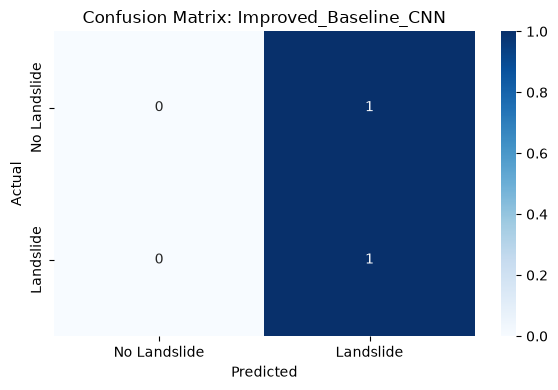

Confusion matrix saved.
ROC-AUC Score: 0.0000

--- Evaluating: ResNet50_FineTuned ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

No Landslide       0.50      1.00      0.67         1
   Landslide       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Art_of_Coding\visionbased_grp\-Vision-Based-Landslide-Forecasting-Using-Satellite-Imagery\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defin

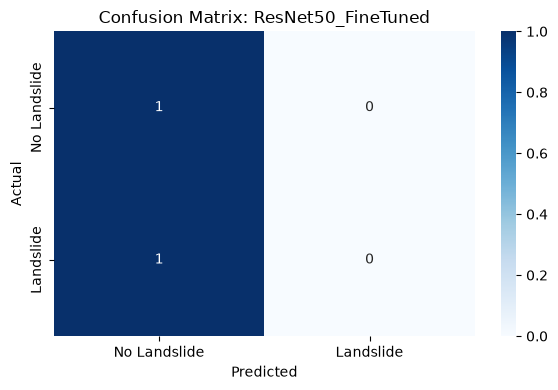

Confusion matrix saved.
ROC-AUC Score: 0.0000

Done! Check the saved confusion matrix images.


In [19]:
def evaluate_model(model, name, test_gen):
    print(f'\n{"="*40}')
    print(f'--- Evaluating: {name} ---')
    print(f'{"="*40}')
    predictions = model.predict(test_gen)
    y_pred  = (predictions > 0.5).astype(int).flatten()
    y_true  = test_gen.classes
    y_score = predictions.flatten()

    print(classification_report(y_true, y_pred, target_names=['No Landslide', 'Landslide']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Landslide', 'Landslide'],
                yticklabels=['No Landslide', 'Landslide'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    print(f'Confusion matrix saved.')

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f'ROC-AUC Score: {auc:.4f}')
    except Exception as e:
        print(f'AUC error: {e}')

evaluate_model(baseline_model, 'Improved_Baseline_CNN', cnn_test_gen)
evaluate_model(resnet_model,   'ResNet50_FineTuned',    resnet_test_gen)
print('\nDone! Check the saved confusion matrix images.')